In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

REPO = Path('..').resolve()
DATASET_DIR = (REPO / 'results' /
    'mle_distributions_R20_N200_A1000000_muXStd10.0um_muVxStd10.0um_sigX100um_sigVx100um'
    '_sigXStd10.0um_sigVxStd10.0um_phi0random_sig_A0.100_f0.3000')

def load_runs(prefix):
    runs = []
    for pkl in sorted(DATASET_DIR.glob(f'{prefix}_run_*.pkl')):
        with open(pkl, 'rb') as f:
            runs.append(pickle.load(f))
    return runs

moment_runs = load_runs('map_moment')
prior_runs  = load_runs('map_prior')
print(f'Loaded {len(moment_runs)} map_moment runs, {len(prior_runs)} map_prior runs')

As_true = moment_runs[0]['As_true']
Ac_true = moment_runs[0]['Ac_true']
print(f'As_true={As_true:.4f}  Ac_true={Ac_true:.4f}')


Loaded 20 map_moment runs, 20 map_prior runs
As_true=0.0878  Ac_true=0.0479


In [2]:
def collect(runs):
    return np.array([r['beta_hat'] for r in runs])   # (n_runs, 2)

beta_moment = collect(moment_runs)
beta_prior  = collect(prior_runs)

for label, betas in [('MAP-moment', beta_moment), ('MAP-prior', beta_prior)]:
    print(f'{label}:  As = {betas[:,0].mean():.4f} ± {betas[:,0].std():.4f}'
          f'   Ac = {betas[:,1].mean():.4f} ± {betas[:,1].std():.4f}')
print(f'Truth:      As = {As_true:.4f}             Ac = {Ac_true:.4f}')


MAP-moment:  As = 0.0885 ± 0.0025   Ac = 0.0474 ± 0.0021
MAP-prior:  As = 0.0878 ± 0.0030   Ac = 0.0476 ± 0.0024
Truth:      As = 0.0878             Ac = 0.0479


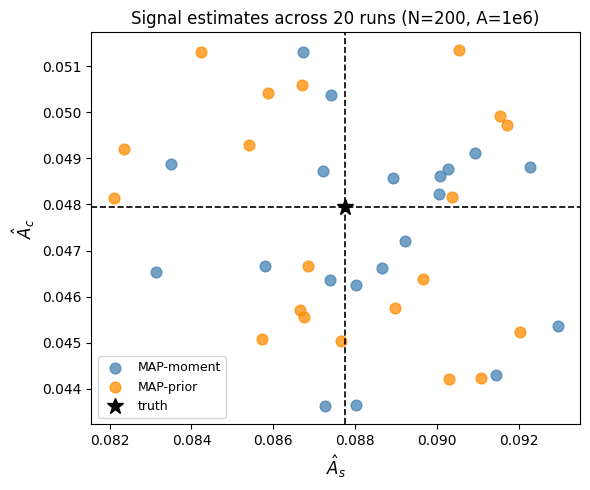

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))

estimators = [('MAP-moment', beta_moment, 'steelblue'),
              ('MAP-prior',  beta_prior,  'darkorange')]

for label, betas, color in estimators:
    ax.scatter(betas[:,0], betas[:,1], s=60, alpha=0.75, color=color, label=label)

ax.axvline(As_true, color='k', lw=1.2, ls='--')
ax.axhline(Ac_true, color='k', lw=1.2, ls='--')
ax.plot(As_true, Ac_true, 'k*', ms=12, label='truth', zorder=5)
ax.set_xlabel(r'$\hat{A}_s$', fontsize=12)
ax.set_ylabel(r'$\hat{A}_c$', fontsize=12)
ax.set_title('Signal estimates across 20 runs (N=200, A=1e6)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


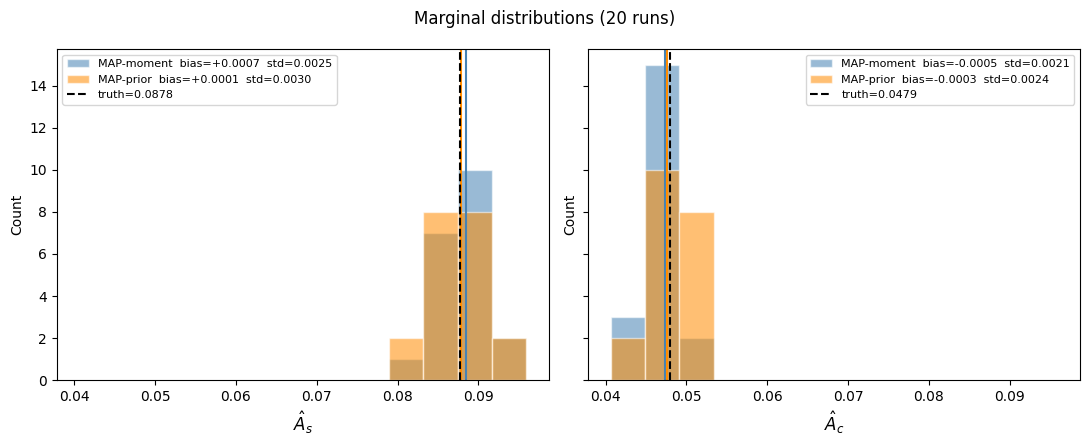

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

truths = [As_true, Ac_true]
param_labels = [r'$\hat{A}_s$', r'$\hat{A}_c$']
estimators = [('MAP-moment', beta_moment, 'steelblue'),
              ('MAP-prior',  beta_prior,  'darkorange')]

bins = np.linspace(
    min(beta_moment.min(), beta_prior.min()) - 0.003,
    max(beta_moment.max(), beta_prior.max()) + 0.003,
    14)

for col, (param_label, truth) in enumerate(zip(param_labels, truths)):
    ax = axes[col]
    for est_label, betas, color in estimators:
        vals = betas[:, col]
        bias = vals.mean() - truth
        ax.hist(vals, bins=bins, color=color, alpha=0.55, edgecolor='white',
                label=f'{est_label}  bias={bias:+.4f}  std={vals.std():.4f}')
        ax.axvline(vals.mean(), color=color, lw=1.5, ls='-')
    ax.axvline(truth, color='k', lw=1.5, ls='--', label=f'truth={truth:.4f}')
    ax.set_xlabel(param_label, fontsize=12)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Marginal distributions (20 runs)', fontsize=12)
plt.tight_layout()
plt.show()


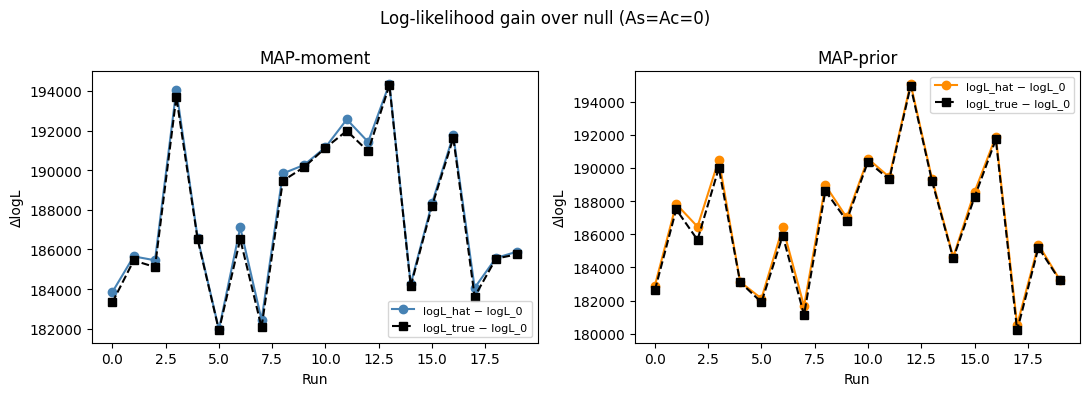

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, runs, label, color in zip(
        axes,
        [moment_runs, prior_runs],
        ['MAP-moment', 'MAP-prior'],
        ['steelblue', 'darkorange']):
    lhat  = np.array([r['logL_hat']  for r in runs])
    ltrue = np.array([r['logL_true'] for r in runs])
    lzero = np.array([r['logL_zero'] for r in runs])
    idx = np.arange(len(runs))
    ax.plot(idx, lhat  - lzero, 'o-',  color=color, label='logL_hat − logL_0')
    ax.plot(idx, ltrue - lzero, 's--', color='k',   label='logL_true − logL_0')
    ax.set_xlabel('Run')
    ax.set_ylabel('ΔlogL')
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.suptitle('Log-likelihood gain over null (As=Ac=0)')
plt.tight_layout()
plt.show()


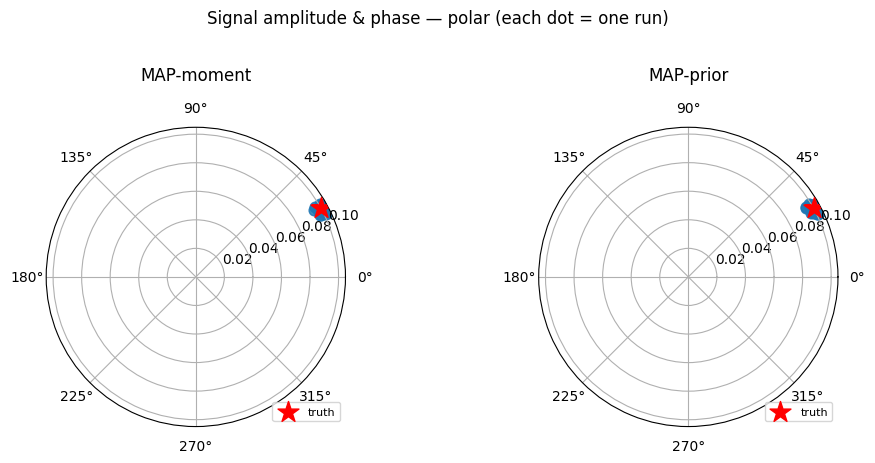

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), subplot_kw={'projection': 'polar'})

A_true   = np.sqrt(As_true**2 + Ac_true**2)
phi_true = np.arctan2(Ac_true, As_true)

for ax, betas, label in zip(axes, [beta_moment, beta_prior], ['MAP-moment', 'MAP-prior']):
    A_hat   = np.sqrt(betas[:,0]**2 + betas[:,1]**2)
    phi_hat = np.arctan2(betas[:,1], betas[:,0])
    ax.scatter(phi_hat, A_hat, s=60, alpha=0.85)
    ax.scatter([phi_true], [A_true], marker='*', s=250, color='red', zorder=5, label='truth')
    ax.set_title(label, pad=15)
    ax.legend(fontsize=8, loc='lower right')

plt.suptitle('Signal amplitude & phase — polar (each dot = one run)', y=1.02)
plt.tight_layout()
plt.show()
